<a href="https://colab.research.google.com/github/awoznica05/Projekt-na-programowanie/blob/main/programowanie_projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wczytanie danych

In [57]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [58]:
!wget -O /content/Gaming_Academic_Performance.csv https://raw.githubusercontent.com/awoznica05/Projekt-na-programowanie/main/Gaming_Academic_Performance.csv

def load_dataset(dataset_path="/content/Gaming_Academic_Performance.csv"):
  return pd.read_csv(dataset_path)

dataset = load_dataset()

--2026-06-10 12:42:40--  https://raw.githubusercontent.com/awoznica05/Projekt-na-programowanie/main/Gaming_Academic_Performance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 606878 (593K) [text/plain]
Saving to: ‘/content/Gaming_Academic_Performance.csv’

/content/Gaming_Aca 100%[===================>] 592.65K  --.-KB/s    in 0.04s   

2026-06-10 12:42:40 (13.9 MB/s) - ‘/content/Gaming_Academic_Performance.csv’ saved [606878/606878]



#Przegląd danych

In [59]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [60]:
dataset.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [61]:
dataset["gender"].value_counts()

,count
gender,
Male,3904
Female,3803
Other,293


In [62]:
dataset["gaming_genre"].value_counts()

,count
gaming_genre,
FPS,3187
RPG,2408
Casual,2405


In [63]:
dataset["stress_level"].value_counts()

,count
stress_level,
Medium,4247
Low,2743
High,1010


In [64]:
dataset.head(5)

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


#Wstępna analiza

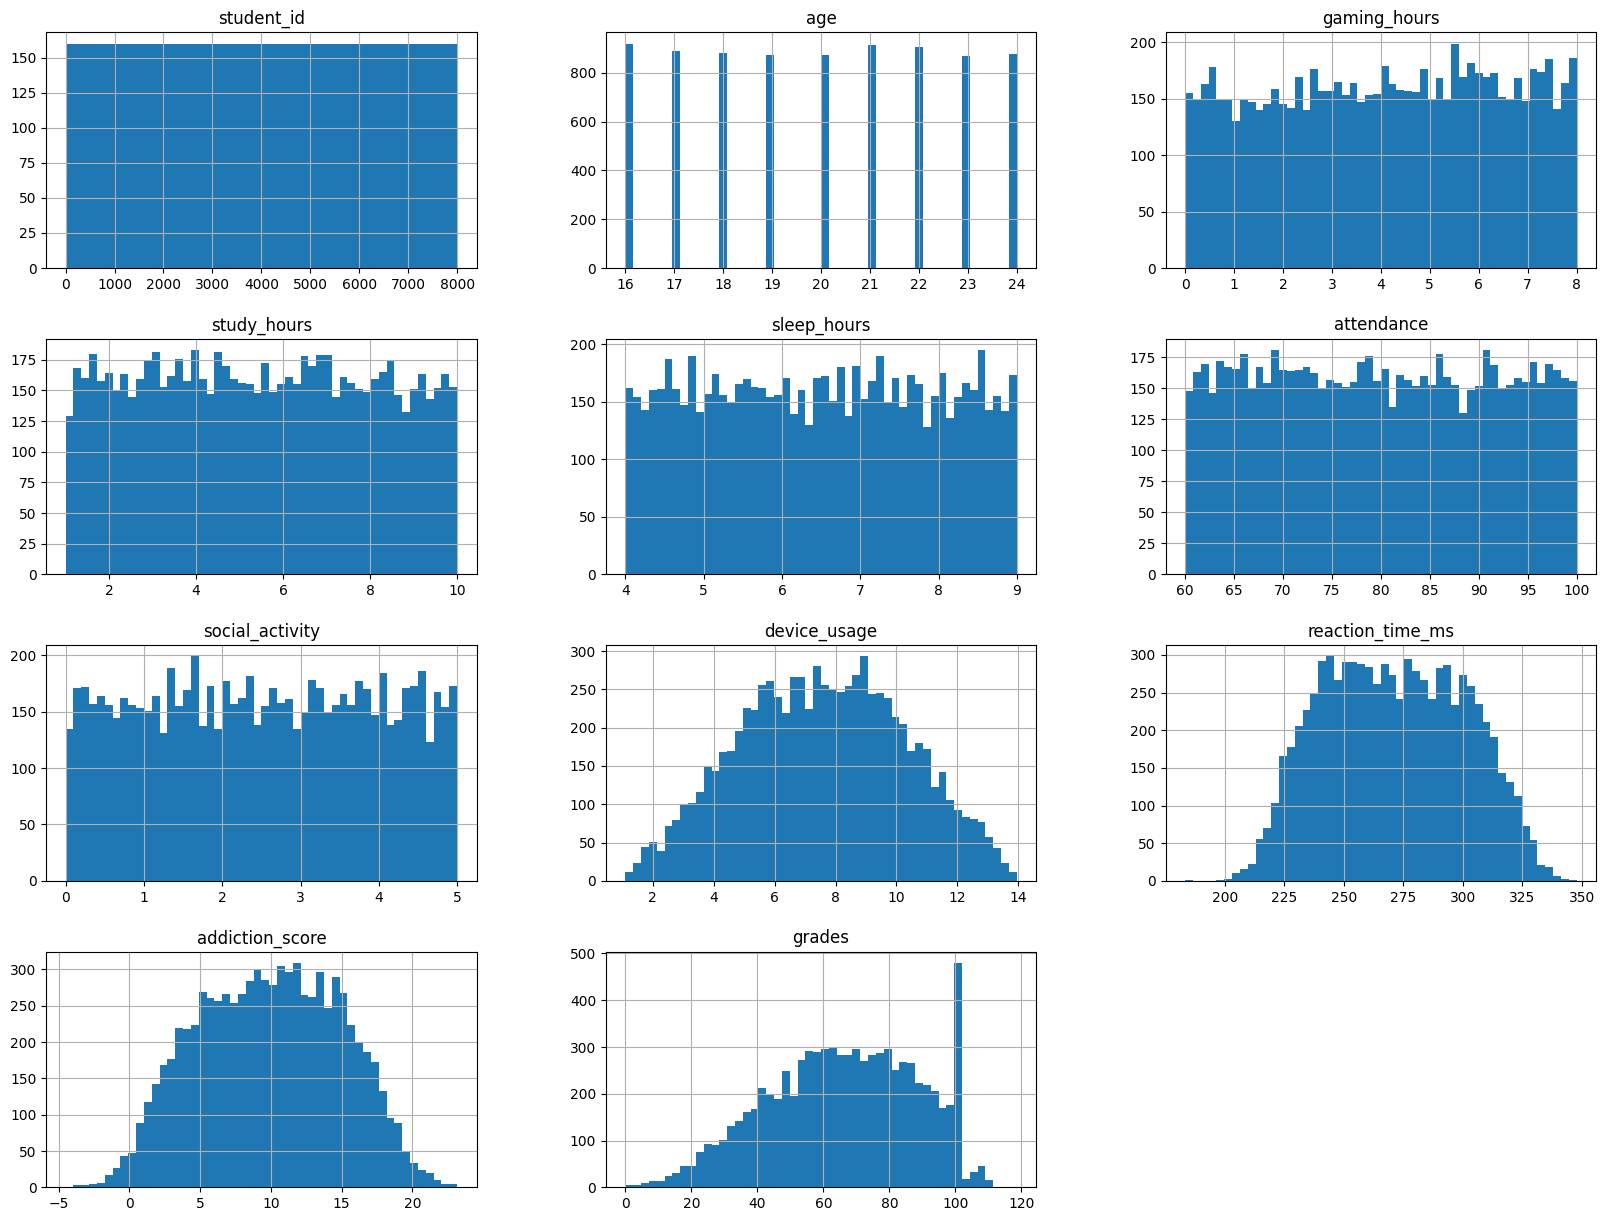

In [65]:
%matplotlib inline
import matplotlib.pyplot as plt
dataset.hist(bins=50, figsize=(20,15))
plt.show()

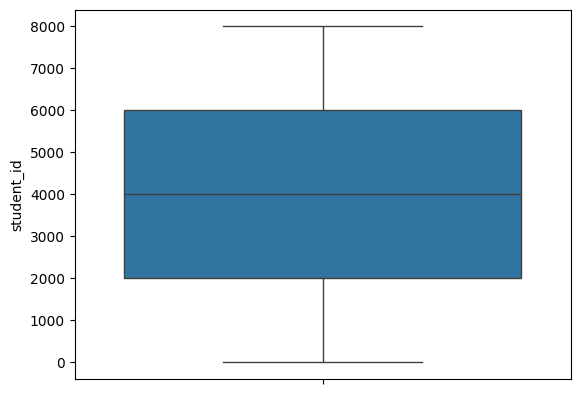

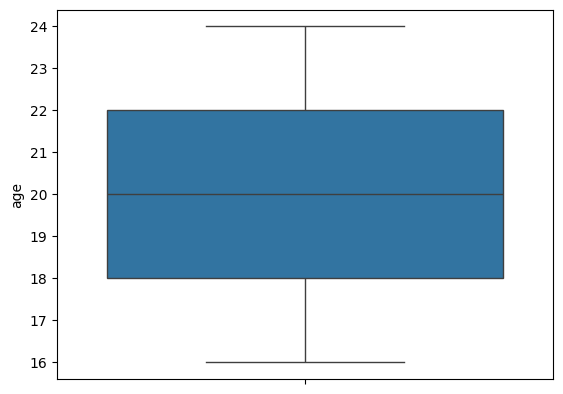

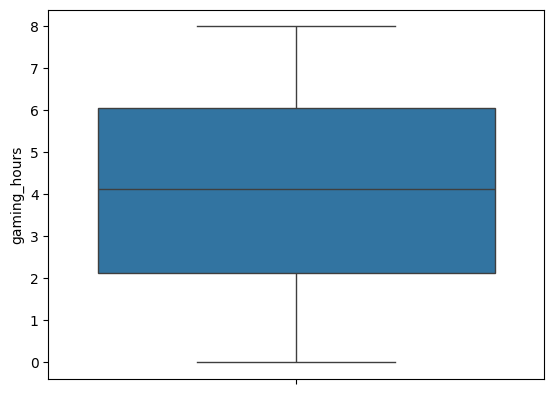

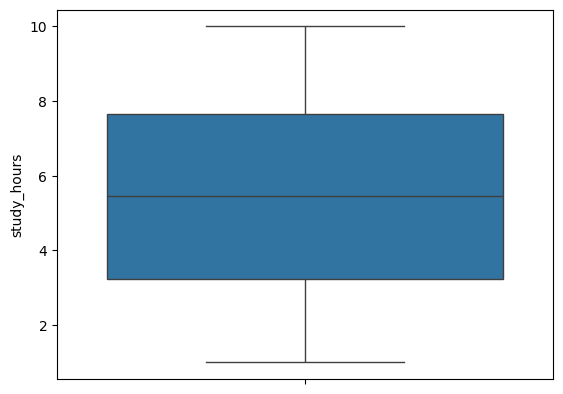

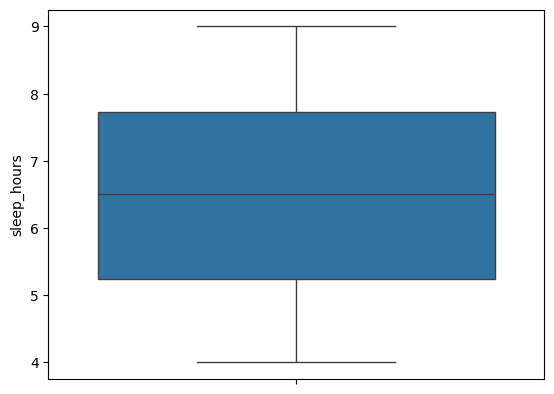

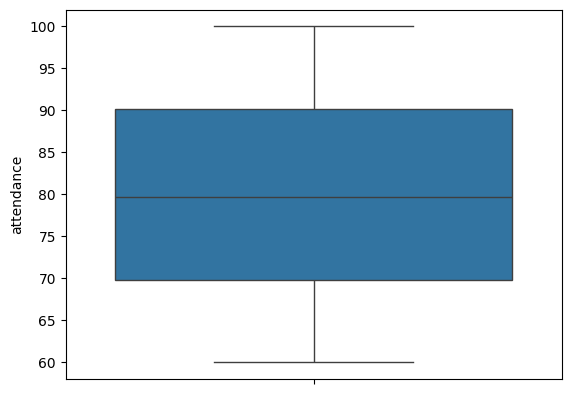

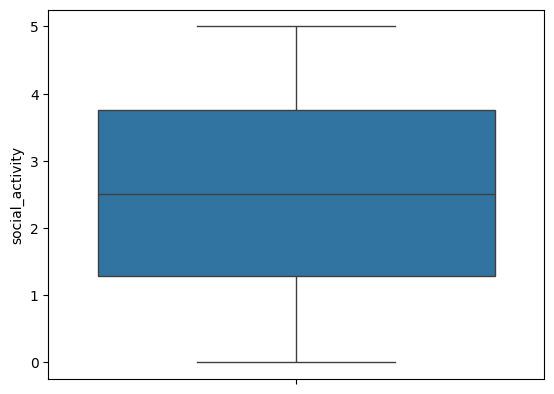

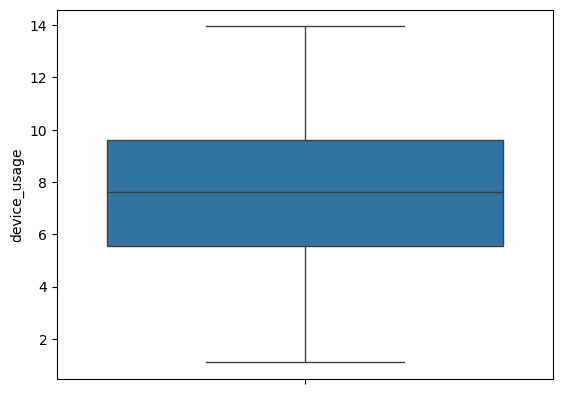

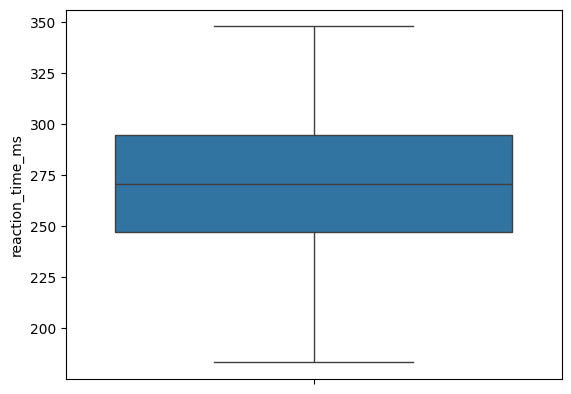

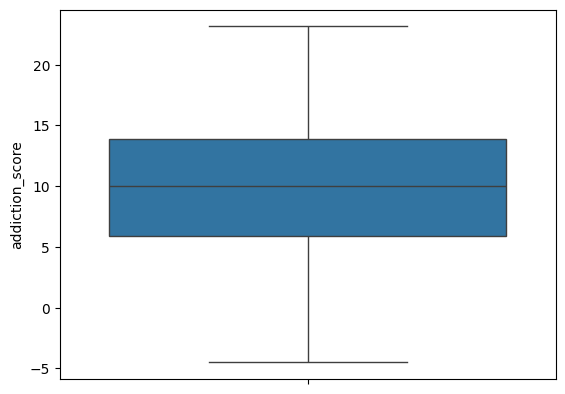

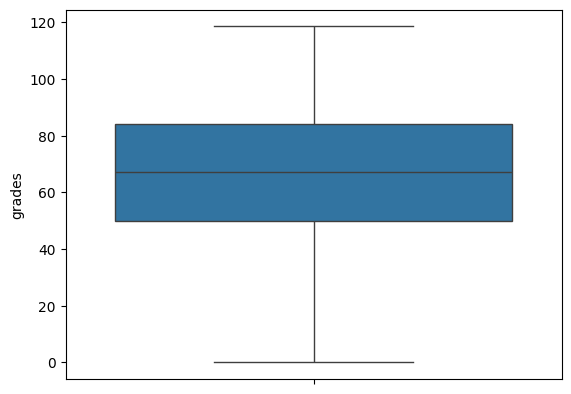

In [66]:
#Sprawdzamy, czy są jacyś outlierzy
import seaborn as sns
for feature in dataset.columns.values:
  if not isinstance(dataset[feature].iloc[0], str): #wykresy tylko dla kolumn z danymi liczbowymi
    sns.boxplot(y=dataset[feature])
    plt.show()

#Czyszczenie danych

In [67]:
#Usuwamy oceny większe niż 100% i duplikaty
#Nie usuwamy outliers, ponieważ z boxplotów wynika, że ich nie ma
clean_dataset = dataset.copy()
clean_dataset = clean_dataset[clean_dataset.grades < 100]
clean_dataset = clean_dataset.drop_duplicates()

In [68]:
clean_dataset.shape

(7427, 14)

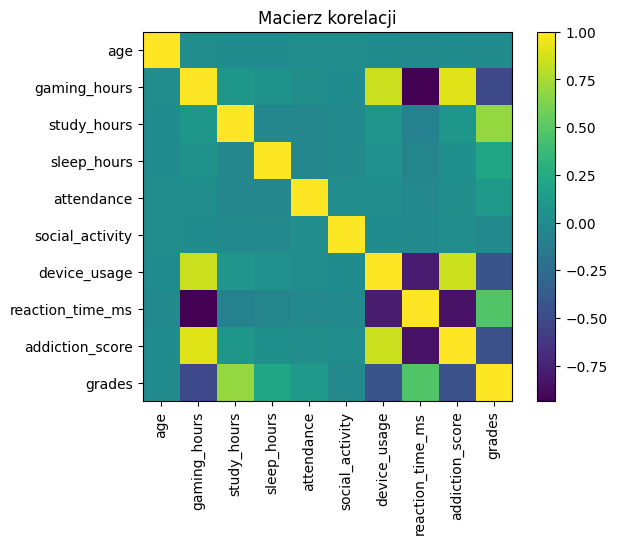

In [69]:
#Tworzymy macierz korelacji wyczyszczonych danych
corr = clean_dataset[['age', 'gaming_hours', 'study_hours', 'sleep_hours',
       'attendance', 'social_activity', 'device_usage', 'reaction_time_ms',
       'addiction_score', 'grades']].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Macierz korelacji")
plt.show()

In [70]:
#<333
#uwu good luck!!

#Przygotowanie danych do uczenia, pipeline

In [71]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(clean_dataset, test_size=0.2, random_state=42)

x = train_set.drop(["grades"], axis=1)
y = train_set["grades"].copy()

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [73]:
ciągłe = ['student_id', 'age', 'gaming_hours', 'study_hours', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score',
       'sleep_hours', 'attendance'] # 'grades' removed
kategorie = ['gender', 'gaming_genre', 'stress_level']

ciągłe_pipeline = Pipeline([
  ('std_scaler', StandardScaler()),
])
kategorie_pipeline = Pipeline([
  ('one_hot', OneHotEncoder()),
])

pipeline = ColumnTransformer([
  ("num_pipeline", ciągłe_pipeline, ciągłe),
  ("cat_pipeline", kategorie_pipeline, kategorie),
])

prepared_dataset = pipeline.fit_transform(clean_dataset)

In [74]:
prepared_dataset.shape

(7427, 19)

#Regresja liniowa

In [75]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
x_train_transformed = pipeline.transform(x)
lin_reg.fit(x_train_transformed, y)

LinearRegression()

In [76]:
#Predykcja targetów
x_test_transformed = pipeline.transform(x)
predictions = lin_reg.predict(x_test_transformed)

In [77]:
#Sprawdzenie poprawności modelu
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 40.18
Root Mean Squared Error: 6.34
R-squared: 0.91


#Random search + Random Forest

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(x_train_transformed, y)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a770f7f6660>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a7713c20320>},
                   random_state=42, scoring='neg_mean_squared_error')

In [79]:
#Predykcja targetów
predictions2 = rnd_search.predict(x_test_transformed)

In [80]:
#Sprawdzenie poprawnośći modelu
mse = mean_squared_error(y, predictions2)
rmse2 = np.sqrt(mse)
r2 = r2_score(y, predictions2)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 5.22
Root Mean Squared Error: 6.34
R-squared: 0.99


#Porównanie dwóch modeli

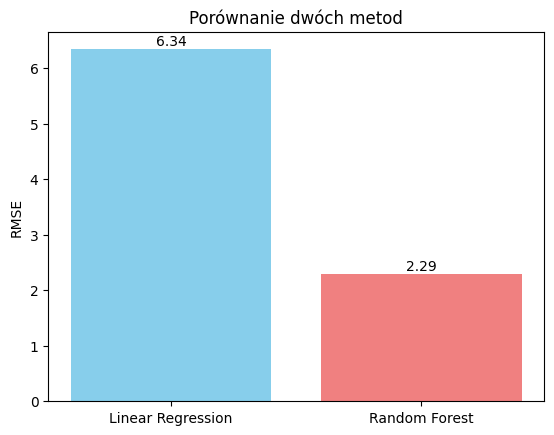

In [81]:
kategorie = ['Linear Regression', 'Random Forest']
wartosci = [rmse, rmse2]

plt.bar(kategorie, wartosci, color=['skyblue', 'lightcoral'])
plt.title("Porównanie dwóch metod")
plt.ylabel('RMSE')
for i, wartosc in enumerate(wartosci):
    plt.text(i, wartosc + 0.02, f'{wartosc:.2f}', ha='center', va='bottom')
plt.show()